In [27]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [28]:
from value import Value
from graph import draw_dot

In [29]:
a = Value(2.0)
b = Value(4.0)

In [30]:
a - b

Value(val = -2.0)

In [31]:
a.exp()

Value(val = 7.38905609893065)

In [32]:
import numpy as np
import matplotlib as plt

In [33]:

x1 = Value(2.0, label = 'x1')
x2 = Value(0.0, label='x2')
w1 = Value(-3.0,label='w1')
w2 = Value(1.0, label='w2')

b = Value(6.8813735870195432, label='b')

x1w1 = x1*w1; x1w1.label = 'x1 * w1'
x2w2 = x2*w2; x2w2.label = 'x2 * w2'

x1w1x2w2 = x1w1 + x2w2; x1w1x2w2.label = 'x1 * w1 + x2 * w2'

n = x1w1x2w2 + b; n.label = 'n'
o = n.tanh(); o.label = 'o'
o.backward()

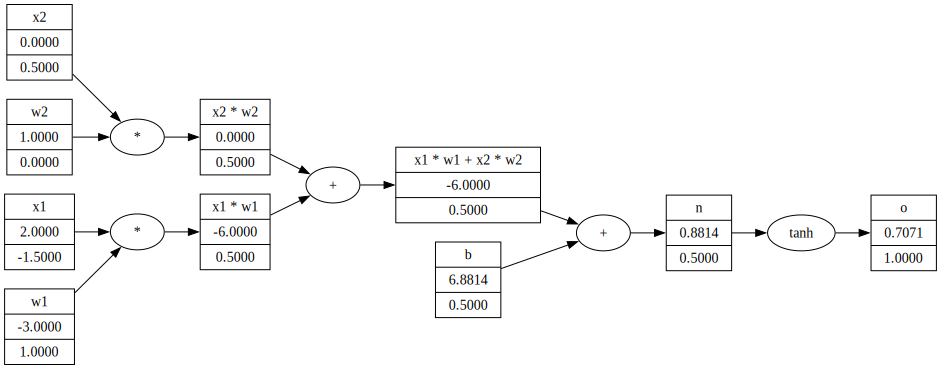

In [34]:
draw_dot(o)

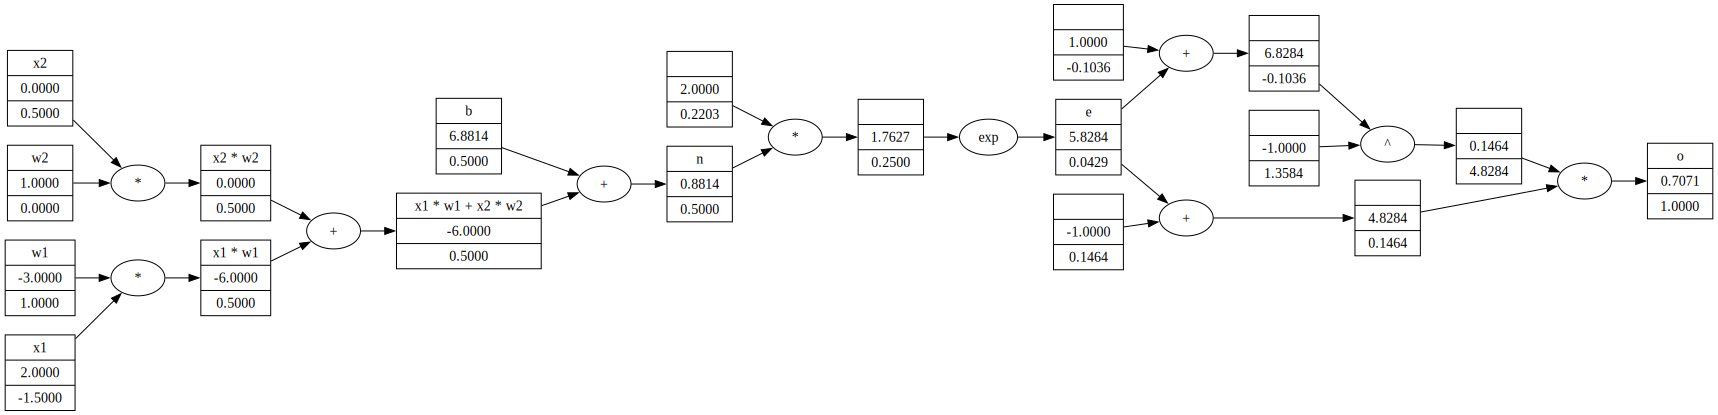

In [35]:

from matplotlib.pyplot import draw


x1 = Value(2.0, label = 'x1')
x2 = Value(0.0, label='x2')
w1 = Value(-3.0,label='w1')
w2 = Value(1.0, label='w2')

b = Value(6.8813735870195432, label='b')

x1w1 = x1*w1; x1w1.label = 'x1 * w1'
x2w2 = x2*w2; x2w2.label = 'x2 * w2'

x1w1x2w2 = x1w1 + x2w2; x1w1x2w2.label = 'x1 * w1 + x2 * w2'

n = x1w1x2w2 + b; n.label = 'n'

e = (2*n).exp(); e.label = 'e'
o = (e - 1) / (e + 1); o.label = 'o'
o.backward()
draw_dot(o)


In [36]:
import torch

In [37]:
x1 = torch.Tensor([2.0]).double()
w1 = torch.Tensor([-3.0]).double()
x2 = torch.Tensor([0.0]).double()
w2 = torch.Tensor([1.0]).double()

x1.requires_grad = True
x2.requires_grad = True
w1.requires_grad = True
w2.requires_grad = True

b = torch.Tensor([6.8813735870195432]).double()
b.requires_grad = True

n = x1*w1+x2*w2+b

o = torch.tanh(n)
print(o)

o.backward()

print(f'x2: {x2.grad}')

tensor([0.7071], dtype=torch.float64, grad_fn=<TanhBackward0>)
x2: tensor([0.5000], dtype=torch.float64)


In [38]:
from neuron import MLP

In [39]:
x = [2.0, -1.0, 1.5]
n = MLP(3, [4, 4, 1])
output = n(x)

In [40]:
output

Value(val = -0.1425952360814127)

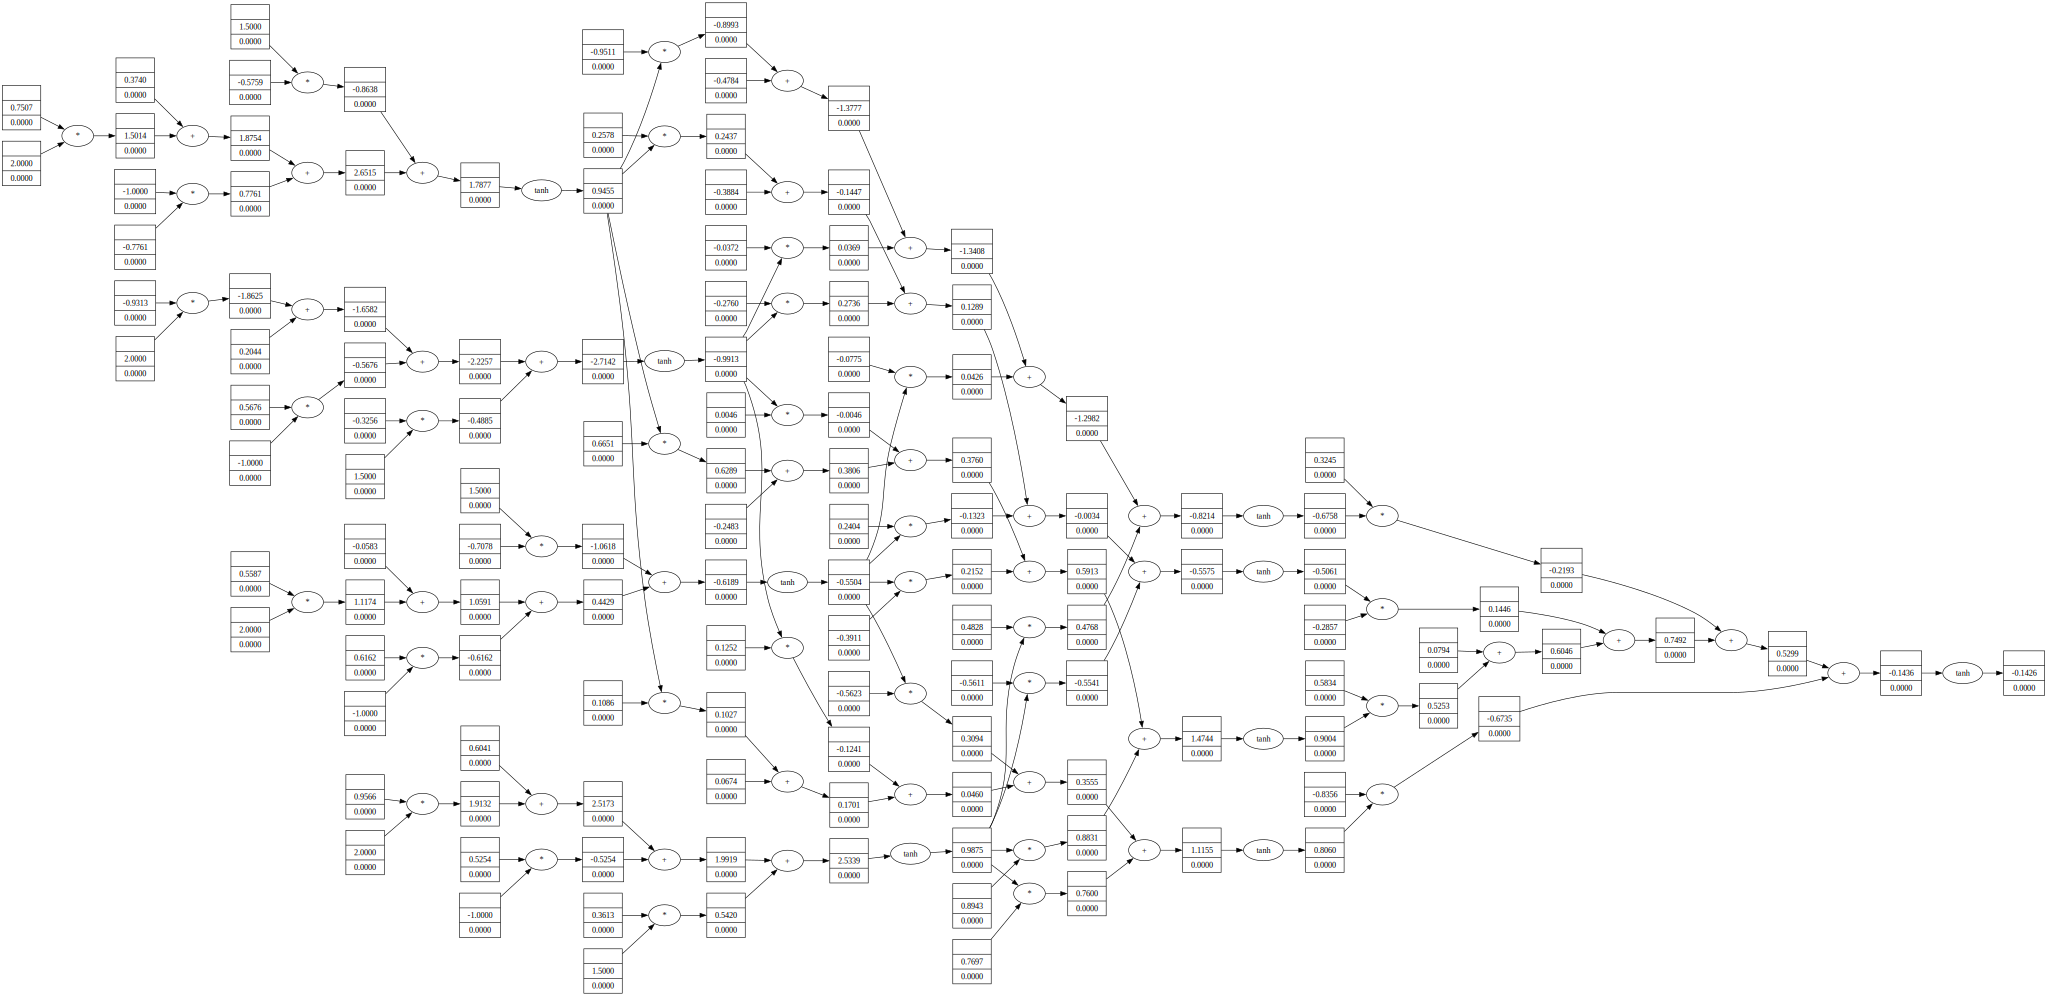

In [41]:
draw_dot(output)

In [42]:
xs = [
    [2.0, 3.0, -1.0],
    [3.0, -1.0, 0.5],
    [0.5, 1.0, 1.0],
    [1.0, 1.0, -1.0]
]
ys = [1.0, -1.0, -1.0, 1.0]

In [43]:
n = MLP(3, [4, 4, 1])

ypred = [n(x) for x in xs]
ypred

[Value(val = -0.33966669700233953),
 Value(val = -0.09520104830911025),
 Value(val = 0.3486247925760965),
 Value(val = -0.5807193807991186)]

In [44]:
ypred[0] - ys[0]

Value(val = -1.3396666970023396)

In [45]:
loss = sum([(yp - y) ** 2 for y, yp in zip(ys, ypred)])
loss

Value(val = 6.930830594022961)

In [46]:
loss.backward()

In [47]:
len(n._params())

41

In [48]:
n._params()

[Value(val = 0.9156768477885162),
 Value(val = 0.6472589096675023),
 Value(val = -0.9304970958796419),
 Value(val = 0.3186152155834123),
 Value(val = -0.6896560740969717),
 Value(val = -0.7626778920568651),
 Value(val = -0.7073144025097826),
 Value(val = 0.2218237733884556),
 Value(val = -0.2513689527903271),
 Value(val = 0.38327544480800646),
 Value(val = 0.571118317728317),
 Value(val = -0.35766967319860465),
 Value(val = -0.3616472386114271),
 Value(val = -0.9463849608050041),
 Value(val = 0.4744957741834388),
 Value(val = 0.33188274762962844),
 Value(val = -0.22123002894684274),
 Value(val = -0.3488824310314729),
 Value(val = -0.9419202017506854),
 Value(val = 0.09514576535620889),
 Value(val = -0.5406408901566087),
 Value(val = 0.659530115228403),
 Value(val = -0.11322052572080277),
 Value(val = 0.05290972767192348),
 Value(val = 0.34078919211382974),
 Value(val = -0.4150092444580964),
 Value(val = 0.509003816141856),
 Value(val = 0.2759614417893794),
 Value(val = -0.8349622521529

In [49]:
learning_rate = 0.1
steps = 100
for i in range(steps):
    #forward pass
    ypred = [n(x) for x in xs]
    loss = sum([(yp - y) ** 2 for y, yp in zip(ys, ypred)])

    #backward pass
    for param in n._params():
        param.grad = 0.0

    loss.backward()

    #update
    for param in n._params():
        param.val += -learning_rate * param.grad

    print(i, loss)

0 Value(val = 6.930830594022961)
1 Value(val = 4.046579615144295)
2 Value(val = 3.499130970265006)
3 Value(val = 3.174407988550657)
4 Value(val = 2.969644408295844)
5 Value(val = 2.8422992068545474)
6 Value(val = 2.750453624544638)
7 Value(val = 2.6696641445332294)
8 Value(val = 2.5800495570753004)
9 Value(val = 2.449396779534112)
10 Value(val = 2.180278598207379)
11 Value(val = 1.4294313130343914)
12 Value(val = 0.5154706367877928)
13 Value(val = 0.22075912062850173)
14 Value(val = 0.13064227351783095)
15 Value(val = 0.09755817746108104)
16 Value(val = 0.07784343866462258)
17 Value(val = 0.06466158181138613)
18 Value(val = 0.055230063797728865)
19 Value(val = 0.04815335838224213)
20 Value(val = 0.04265152253317464)
21 Value(val = 0.0382542818533595)
22 Value(val = 0.034661271116745884)
23 Value(val = 0.03167171657853194)
24 Value(val = 0.029146363000436055)
25 Value(val = 0.026985618053127654)
26 Value(val = 0.025116390241628726)
27 Value(val = 0.02348383799152761)
28 Value(val = 0.02